# Олимпиада по Кибериммунной разработке 

## Создание конструктивно защищённой автономной роботизированной платформы бурения тоннелей 

## Модуль 2

## О документе

Модуль 2 для олимпиады по кибериммунной разработке

Видео разбор:

#### Задача данного модуля

Для заданных начальной точки (20, 20 светло серый квадратик на карте) и конечной точки (691, 68 светло синий квадратик на карте) создать маршрут, содержащий **не менее пяти** промежуточных путевых точек (точка маршрута) и **не более десяти**. Запустите симуляцию и убедитесь, что АРПБТ успешно проходит этот маршрут.

Учитывайте геометрические особенности тоннеля, АРПБТ не должен задеть стены шахты. В этом поможет модуль Датчиков.

На рисунке 1 изображена диаграмма потоков данных с учетом добавления модуля Датчиков, так как используется виртуальная среда, а сами датчики (лидар, ультразвуковые и т.д.) для определения расстояния используют отражение волны, мы будем запрашивать координаты и общую схему шахты, для математического расчёта расстояния.

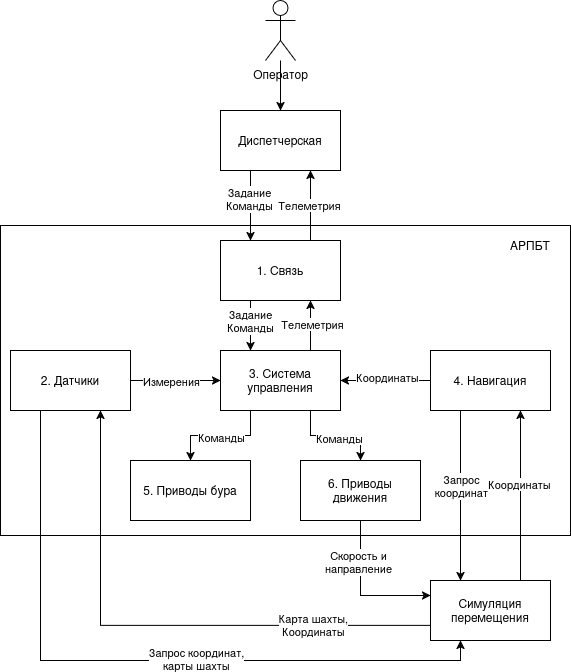

Рисунок 1. Диаграмма потоков данных с модулем Датчиков

**Задачи:**

1. Необходимо дописать взаимодействие между сущностями Sensors и ControlSystem.
2. Необходимо реализовать движение по точкам маршрута, по аналогии с движением по контрольным точкам, только в них бурить тоннель не нужно.
3. ***(Опционально)*** АРПБТ должен как можно быстрее пройти маршрут. (**Вся работы по ускорению АРПБТ происходит в блокноте, в папке src нет необходимости изменений**)

Перенесите реализованный код сущности **ControlSystem** из модуля 1 в данный модуль

Общий пул очереди

In [1]:
from multiprocessing import Queue

events_queue = Queue()

Классы Event

In [2]:
from dataclasses import dataclass


# формат управляющих команд
@dataclass
class ControlEvent:
    operation: str


@dataclass
class Event:
    source: str  # отправитель
    destination: str  # получатель
    operation: str  # чего хочет (запрашиваемое действие)
    parameters: str  # с какими параметрами

Создадим общего менеджера очереди

In [3]:
from multiprocessing import Queue, Process
from multiprocessing.queues import Empty
from time import sleep


# Класс
class QueueManage(Process):

    def __init__(self, events_q: Queue):
        # вызываем конструктор базового класса
        super().__init__()
        self._events_q = events_q  # очередь событий входящие сообщения
        self._control_q = (
            Queue()
        )  # очередь управляющих команд (например, для остановки монитора)
        self._entity_queues = {}  # словарь очередей известных монитору сущностей
        self._force_quit = False  # флаг завершения работы монитора

    # регистрация очереди новой сущности
    def add_entity_queue(self, entity_id: str, queue: Queue):
        # print(f"[ИНФО] регистрируем сущность {entity_id}")
        self._entity_queues[entity_id] = queue

    def _proceed(self, event):
        # print(f'[ИНФО] отправляем запрос {event}')
        try:
            # найдём очередь получателя события
            dst_q: Queue = self._entity_queues[event.destination]
            # и положим запрос в эту очередь
            dst_q.put(event)
        except Exception as e:
            # например, запрос пришёл от или для неизвестной сущности
            print(f"[ИНФО] ошибка выполнения запроса {e}")

    # основной код работы монитора безопасности
    def run(self):
        # print('[ИНФО] старт')

        # в цикле проверяет наличие новых событий,
        # выход из цикла по флагу _force_quit
        while self._force_quit is False:
            event = None
            try:
                # ожидание сделано неблокирующим,
                # чтобы можно было завершить работу монитора,
                # не дожидаясь нового сообщения
                event = self._events_q.get_nowait()
                self._proceed(event)
            except Empty:
                # сюда попадаем, если новых сообщений ещё нет,
                # в таком случае немного подождём
                sleep(0.5)
            except Exception as e:
                # что-то пошло не так, выведем сообщение об ошибке
                print(f"[ИНФО] ошибка обработки {e}, {event}")
            self._check_control_q()
        # print('[ИНФО] завершение работы')

    # запрос на остановку для завершения работы
    # может вызываться вне процесса
    def stop(self):
        # поскольку работает в отдельном процессе,
        # запрос помещается в очередь, которая проверяется из процесса
        request = ControlEvent(operation="stop")
        self._control_q.put(request)

    # проверка наличия новых управляющих команд
    def _check_control_q(self):
        try:
            request: ControlEvent = self._control_q.get_nowait()
            #  print(f"[ИНФО] проверяем запрос {request}")
            if isinstance(request, ControlEvent) and request.operation == "stop":
                # поступил запрос на остановку, поднимаем "красный флаг"
                self._force_quit = True
        except Empty:
            # никаких команд не поступило
            pass

#### Сущность ControlSystem

In [4]:
from multiprocessing import Queue, Process
from src.control_systems_calc import update_speed_and_direction


class ControlSystem(Process):

    def __init__(self, events_queue: Queue):
        # вызываем конструктор базового класса
        super().__init__()
        self.events_queue = events_queue
        self._own_queue = Queue()
        self._control_q = (
            Queue()
        )  # очередь управляющих команд (например, для остановки)
        self._force_quit = False
        self._targets_points = []  # Точки маршрута
        self._current_coordinates = None  # Текущие координаты АРПБТ
        self._current_speed = 30  # Скорость АРПБТ
        self._current_direction = 90  # Базовое направление движения АРПБТ в градусах
        self._obstacle_distances = (
            []
        )  # Массив расстояний до препятствий по 6 направлениям
        self._status = (
            ""  # Статус АРПБТ, находится в движении или достигла точки маршрута
        )
        self._counter = 1  # Счётчик пройденных точек маршрута
        self.max_speed = 30

    # выдаёт собственную очередь для взаимодействия
    def entity_queue(self):
        return self._own_queue

    def control_entity_queue(self):
        return self._control_q

    def send_to_drill(self):
        event = None
        event = Event(
            source=self.__class__.__name__,
            destination="Drill",
            operation="drilling",
            parameters=None,
        )
        self.events_queue.put(event)

    def mission_move(self):
        if (
            self._current_coordinates and self._obstacle_distances is not None
        ):  # Проверка первичной инициализации АРПБТ
            if len(self._targets_points) > 0:
                target_point = self._targets_points[0]
                self._current_speed, self._current_direction, self._status = (
                    update_speed_and_direction(
                        (
                            self._current_coordinates["x"],
                            self._current_coordinates["y"],
                        ),
                        (target_point["x"], target_point["y"]),
                        self._current_speed,
                        self._current_direction,
                        self._obstacle_distances,
                        self.max_speed,
                    )
                )

                if self._status == "success":
                    if target_point["type"] == "checkpoint":

                        print(
                            f"[{self.__class__.__name__}] точка бурения {self._counter} достигнута"
                        )
                        data = {"speed": 0, "direction": self._current_direction}
                        event = Event(
                            source=self.__class__.__name__,
                            destination="Servos",
                            operation="set_velocity",
                            parameters=data,
                        )
                        self.events_queue.put(event)

                        self.send_to_drill()

                    elif target_point["type"] == "waypoint":
                        print(
                            f"[{self.__class__.__name__}] точка {self._counter} маршрута движения достигнута"
                        )
                    self._status = ""
                    self._counter += 1
                    self._targets_points.pop(0)

                data = {
                    "speed": self._current_speed,
                    "direction": self._current_direction,
                }

                # print(f'[{self.__class__.__name__}] отправляем сигналы управления приводами движения {json.dumps(data)}')

                event = Event(
                    source=self.__class__.__name__,
                    destination="Servos",
                    operation="set_velocity",
                    parameters=data,
                )
                self.events_queue.put(event)

    # основной код сущности
    def run(self):
        print(f"[{self.__class__.__name__}] старт")
        while self._force_quit is False:
            sleep(0.02)
            event = None
            self._check_event_queue()
            self._check_control_q()
            self.mission_move()
            
            if self._current_coordinates:
                telemetry_event = Event(
                    source=self.__class__.__name__,
                    destination="Communication",
                    operation="telemetry",
                    parameters=self._current_coordinates
                )
                self.events_queue.put(telemetry_event)

        print(f"[{self.__class__.__name__}] завершение работы")

    def stop(self):
        # поскольку работает в отдельном процессе,
        # запрос помещается в очередь, которая проверяется из процесса
        request = ControlEvent(operation="stop")
        self._control_q.put(request)

    def _check_control_q(self):
        try:
            request: ControlEvent = self._control_q.get_nowait()
            print(f"[{self.__class__.__name__}] проверяем запрос {request}")
            if isinstance(request, ControlEvent) and request.operation == "stop":
                # поступил запрос на остановку, поднимаем "красный флаг"
                self._force_quit = True
        except Empty:
            # никаких команд не поступило
            pass

    def _check_event_queue(self):
        event = None
        try:
            event: Event = self._own_queue.get_nowait()

            if event.operation == "new_task":
                print(
                    f"[{self.__class__.__name__}] {event.source} прислал новое задание {event.parameters}"
                )
                print(f"[{self.__class__.__name__}] новое задание: {event.parameters}!")
                self._targets_points = event.parameters

            if event.operation == "get_coordinates":
                # print(f"[{self.__class__.__name__}] текущая позиция АРПБТ {event.parameters}")
                self._current_coordinates = event.parameters

            if event.operation == "get_directions":
            # print(f"[{self.__class__.__name__}] текущие измерения расстояний до препятствий АРПБТ {event.parameters}")
                self._obstacle_distances = event.parameters

        except Empty:
            sleep(0.05)
        except Exception as e:
            # что-то пошло не так, выведем сообщение об ошибке
            print(f"[{self.__class__.__name__}] ошибка обработки {e}, {event}")

#### Сущность Sensors

Сущность модуля Датчики, реализует опрос расстояний до препятствий в шахте. Использует для этого 6 направлений опроса (360/6 = 60 градусов это один сектор опроса). Позволяет корректировать движения АРПБТ по тоннелю.

In [5]:
import requests
from src.sensors_calc import calculate_obstacle_distances
from multiprocessing import Queue, Process


class Sensors(Process):

    def __init__(self, events_queue: Queue):
        # вызываем конструктор базового класса
        super().__init__()
        self.events_queue = events_queue
        self._own_queue = Queue()
        self._control_q = Queue()
        self._force_quit = False
        self._config = None

    # выдаёт собственную очередь для взаимодействия
    def entity_queue(self):
        return self._own_queue

    def control_entity_queue(self):
        return self._control_q

    # основной код сущности
    def run(self):
        print(f"[{self.__class__.__name__}] старт")

        response = requests.get(
            "http://127.0.0.1:5000/config"
        )  # URL для получения конфигурации карты шахты
        response.raise_for_status()
        self._config = response.json()

        while self._force_quit is False:
            try:
                sleep(0.02)
                response = requests.get(
                    "http://127.0.0.1:5000/position"
                )  # URL для получения текущих координат
                response.raise_for_status()
                coordinates = response.json()

                obstacle_distances = calculate_obstacle_distances(
                    coordinates["x"],
                    coordinates["y"],
                    self._config["obstacles"],
                    (self._config["field_width"], self._config["field_height"]),
                    30,
                )

                # print(f"[{self.__class__.__name__}]Текущие расстояния до препятствия: {obstacle_distances}")

                event = Event(
                    source=self.__class__.__name__,
                    destination="ControlSystem",
                    operation="get_directions",
                    parameters=obstacle_distances,
                )
                self.events_queue.put(event)
                self._check_control_q()
            except requests.exceptions.RequestException as e:
                print(f"[{self.__class__.__name__}]Ошибка запроса: {e}")
                self._check_control_q()

        print(f"[{self.__class__.__name__}] завершение работы")

    def stop(self):
        # поскольку работает в отдельном процессе,
        # запрос помещается в очередь, которая проверяется из процесса
        request = ControlEvent(operation="stop")
        self._control_q.put(request)

    def _check_control_q(self):
        try:
            request: ControlEvent = self._control_q.get_nowait()
            print(f"[{self.__class__.__name__}] проверяем запрос {request}")
            if isinstance(request, ControlEvent) and request.operation == "stop":
                # поступил запрос на остановку, поднимаем "красный флаг"
                self._force_quit = True
        except Empty:
            # никаких команд не поступило
            pass

#### Сущность Communication

In [6]:
from multiprocessing import Queue, Process


class Communication(Process):

    def __init__(self, events_queue: Queue):
        # вызываем конструктор базового класса
        super().__init__()
        self.events_queue = events_queue
        self._own_queue = Queue()

    # выдаёт собственную очередь для взаимодействия
    def entity_queue(self):
        return self._own_queue

    # основной код сущности
    def run(self):
        print(f"[{self.__class__.__name__}] старт")
        
        # Задаем маршрут для Модуля 2 
        task = [
            {"x": 5, "y": 5, "type": "checkpoint"},
            {"x": 10, "y": 10, "type": "checkpoint"}
        ]
        
        event = Event(
            source=self.__class__.__name__,
            destination="ControlSystem",
            operation="new_task",
            parameters=task,
        )
        self.events_queue.put(event)

        # Цикл ожидания, чтобы процесс не завершался
        while getattr(self, '_force_quit', False) is False:
            if not self._own_queue.empty():
                msg = self._own_queue.get()
                # Здесь будет приходить телеметрия
            sleep(1)
        print(f"[{self.__class__.__name__}] завершение работы")

#### Сущность Navigation

In [7]:
import requests
from multiprocessing import Queue, Process


class Navigation(Process):

    def __init__(self, events_queue: Queue):
        # вызываем конструктор базового класса
        super().__init__()
        self.events_queue = events_queue
        self._own_queue = Queue()
        self._control_q = Queue()
        self._force_quit = False

    # выдаёт собственную очередь для взаимодействия
    def entity_queue(self):
        return self._own_queue

    def control_entity_queue(self):
        return self._control_q

    # основной код сущности
    def run(self):
        print(f"[{self.__class__.__name__}] старт")
        while self._force_quit is False:
            try:
                sleep(0.05)
                response = requests.get(
                    "http://127.0.0.1:5000/position"
                )  # URL для получения текущих координат
                response.raise_for_status()
                coordinates = response.json()
                # print(f"[{self.__class__.__name__}]Текущая позиция: X={coordinates['x']}, Y={coordinates['y']}")
                event = Event(
                    source=self.__class__.__name__,
                    destination="ControlSystem",
                    operation="get_coordinates",
                    parameters=coordinates,
                )
                self.events_queue.put(event)
                self._check_control_q()
            except requests.exceptions.RequestException as e:
                print(f"[{self.__class__.__name__}]Ошибка запроса: {e}")
                self._check_control_q()

        print(f"[{self.__class__.__name__}] завершение работы")

    def stop(self):
        # поскольку работает в отдельном процессе,
        # запрос помещается в очередь, которая проверяется из процесса
        request = ControlEvent(operation="stop")
        self._control_q.put(request)

    def _check_control_q(self):
        try:
            request: ControlEvent = self._control_q.get_nowait()
            print(f"[{self.__class__.__name__}] проверяем запрос {request}")
            if isinstance(request, ControlEvent) and request.operation == "stop":
                # поступил запрос на остановку, поднимаем "красный флаг"
                self._force_quit = True
        except Empty:
            # никаких команд не поступило
            pass

#### Сущность Servos

In [8]:
from multiprocessing import Queue, Process


class Servos(Process):

    def __init__(self, events_queue: Queue):
        # вызываем конструктор базового класса
        super().__init__()
        self.events_queue = events_queue
        self._own_queue = Queue()
        self._control_q = Queue()
        self._force_quit = False

    # выдаёт собственную очередь для взаимодействия
    def entity_queue(self):
        return self._own_queue

    def control_entity_queue(self):
        return self._control_q

    # основной код сущности
    def run(self):
        print(f"[{self.__class__.__name__}] старт")
        while self._force_quit is False:
            self._check_event_queue()
            self._check_control_q()

        print(f"[{self.__class__.__name__}] завершение работы")

    def stop(self):
        # поскольку работает в отдельном процессе,
        # запрос помещается в очередь, которая проверяется из процесса
        request = ControlEvent(operation="stop")
        self._control_q.put(request)

    def _check_event_queue(self):
        event = None
        try:
            event: Event = self._own_queue.get_nowait()
            if event.operation == "set_velocity":
                # print(f"[{self.__class__.__name__}] {event.source} прислал новые параметры управления {event.parameters}")
                try:
                    data = event.parameters
                    response = requests.post(
                        "http://127.0.0.1:5000/set_velocity", json=data
                    )  # URL для обновления параметров скорости и направления движения
                    response.raise_for_status()
                except requests.exceptions.RequestException as e:
                    print(f"[{self.__class__.__name__}]Ошибка запроса: {e}")
        except Empty:
            sleep(0.05)
        except Exception as e:
            # что-то пошло не так, выведем сообщение об ошибке
            print(f"[{self.__class__.__name__}] ошибка обработки {e}, {event}")

    def _check_control_q(self):
        try:
            request: ControlEvent = self._control_q.get_nowait()
            print(f"[{self.__class__.__name__}] проверяем запрос {request}")
            if isinstance(request, ControlEvent) and request.operation == "stop":
                # поступил запрос на остановку, поднимаем "красный флаг"
                self._force_quit = True
        except Empty:
            # никаких команд не поступило
            pass

#### Сущность Drill

In [9]:
from multiprocessing import Queue, Process


class Drill(Process):

    def __init__(self, events_queue: Queue):
        # вызываем конструктор базового класса
        super().__init__()
        self.events_queue = events_queue
        self._own_queue = Queue()
        self._control_q = Queue()
        self._force_quit = False

    # выдаёт собственную очередь для взаимодействия
    def entity_queue(self):
        return self._own_queue

    def control_entity_queue(self):
        return self._control_q

    # основной код сущности
    def run(self):
        print(f"[{self.__class__.__name__}] старт")

        while self._force_quit is False:
            self._check_event_queue()
            self._check_control_q()

        print(f"[{self.__class__.__name__}] завершение работы")

    def stop(self):
        # поскольку работает в отдельном процессе,
        # запрос помещается в очередь, которая проверяется из процесса
        request = ControlEvent(operation="stop")
        self._control_q.put(request)

    def _check_event_queue(self):
        event = None
        try:
            event: Event = self._own_queue.get_nowait()
            if event.operation == "drilling":
                print(f"[{self.__class__.__name__}] бурим тоннель")
        except Empty:
            sleep(0.1)
        except Exception as e:
            # что-то пошло не так, выведем сообщение об ошибке
            print(f"[{self.__class__.__name__}] ошибка обработки {e}, {event}")

    def _check_control_q(self):
        try:
            request: ControlEvent = self._control_q.get_nowait()
            print(f"[{self.__class__.__name__}] проверяем запрос {request}")
            if isinstance(request, ControlEvent) and request.operation == "stop":
                # поступил запрос на остановку, поднимаем "красный флаг"
                self._force_quit = True
        except Empty:
            # никаких команд не поступило
            pass

Инициализация модулей

In [10]:
queue_manager = QueueManage(events_queue)
communication = Communication(events_queue)
control_system = ControlSystem(events_queue)
navigation = Navigation(events_queue)
sensors = Sensors(events_queue)
servos = Servos(events_queue)
drill = Drill(events_queue)

Добавляем в общую очередь все реализованные сущности, можно сказать регистрируем их в менеджере Очереди

In [11]:
queue_manager.add_entity_queue("Communication", communication.entity_queue())
queue_manager.add_entity_queue("ControlSystem", control_system.entity_queue())
queue_manager.add_entity_queue("Navigation", navigation.entity_queue())
queue_manager.add_entity_queue("Sensors", sensors.entity_queue())
queue_manager.add_entity_queue("Servos", servos.entity_queue())
queue_manager.add_entity_queue("Drill", drill.entity_queue())

Запуск симуляции

In [12]:
queue_manager.start()
communication.start()
control_system.start()
navigation.start()
sensors.start()
servos.start()
drill.start()
sleep(160)
queue_manager.stop()
communication.join()
control_system.stop()
navigation.stop()
sensors.stop()
servos.stop()
drill.stop()

[Communication] старт
[ControlSystem] старт
[Navigation] старт
[Sensors] старт
[Servos] старт


Process Sensors-5:


[Drill] старт
[Navigation]Ошибка запроса: HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /position (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7f36ac075790>: Failed to establish a new connection: [Errno 111] Connection refused'))


Traceback (most recent call last):
  File "/opt/conda/lib/python3.9/site-packages/urllib3/connection.py", line 174, in _new_conn
    conn = connection.create_connection(
  File "/opt/conda/lib/python3.9/site-packages/urllib3/util/connection.py", line 95, in create_connection
    raise err
  File "/opt/conda/lib/python3.9/site-packages/urllib3/util/connection.py", line 85, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [Errno 111] Connection refused

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/conda/lib/python3.9/site-packages/urllib3/connectionpool.py", line 703, in urlopen
    httplib_response = self._make_request(
  File "/opt/conda/lib/python3.9/site-packages/urllib3/connectionpool.py", line 398, in _make_request
    conn.request(method, url, **httplib_request_kw)
  File "/opt/conda/lib/python3.9/site-packages/urllib3/connection.py", line 239, in request
    super(HTTPConnection, self).reques

[Navigation]Ошибка запроса: HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /position (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7f36ac002880>: Failed to establish a new connection: [Errno 111] Connection refused'))

...

Traceback (most recent call last):
  File "/opt/conda/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/tmp/ipykernel_1682012/1901185046.py", line 28, in run
    response = requests.get(
  File "/opt/conda/lib/python3.9/site-packages/requests/api.py", line 73, in get
    return request("get", url, params=params, **kwargs)
  File "/opt/conda/lib/python3.9/site-packages/requests/api.py", line 59, in request
    return session.request(method=method, url=url, **kwargs)
  File "/opt/conda/lib/python3.9/site-packages/requests/sessions.py", line 587, in request
    resp = self.send(prep, **send_kwargs)
  File "/opt/conda/lib/python3.9/site-packages/requests/sessions.py", line 701, in send
    r = adapter.send(request, **kwargs)
  File "/opt/conda/lib/python3.9/site-packages/requests/adapters.py", line 565, in send
    raise ConnectionError(e, request=request)
requests.exceptions.ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=5000): Max retr

[Navigation]Ошибка запроса: HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /position (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7f36ac002280>: Failed to establish a new connection: [Errno 111] Connection refused'))
[Navigation]Ошибка запроса: HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /position (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7f36aecfd6a0>: Failed to establish a new connection: [Errno 111] Connection refused'))
[Navigation]Ошибка запроса: HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /position (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7f36aecfdeb0>: Failed to establish a new connection: [Errno 111] Connection refused'))
[Navigation]Ошибка запроса: HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /position (Caused by NewConnectionError('<u

Process Servos-6:
Process Navigation-4:
Process Drill-7:
Process ControlSystem-3:
Process Communication-2:
Process QueueManage-1:
_queue.Empty

During handling of the above exception, another exception occurred:

KeyboardInterrupt
KeyboardInterrupt
KeyboardInterrupt
KeyboardInterrupt
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/conda/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()


KeyboardInterrupt: 

Traceback (most recent call last):
  File "/tmp/ipykernel_1682012/180016178.py", line 39, in _check_event_queue
    event: Event = self._own_queue.get_nowait()
  File "/tmp/ipykernel_1682012/3675667183.py", line 27, in run
    sleep(0.05)
  File "/tmp/ipykernel_1682012/3910422902.py", line 40, in _check_event_queue
    event: Event = self._own_queue.get_nowait()
  File "/opt/conda/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/tmp/ipykernel_1682012/2241367458.py", line 147, in _check_event_queue
    event: Event = self._own_queue.get_nowait()
  File "/tmp/ipykernel_1682012/1725746253.py", line 47, in run
    event = self._events_q.get_nowait()
  File "/opt/conda/lib/python3.9/multiprocessing/queues.py", line 135, in get_nowait
    return self.get(False)
KeyboardInterrupt
  File "/opt/conda/lib/python3.9/multiprocessing/queues.py", line 135, in get_nowait
    return self.get(False)
  File "/tmp/ipykernel_1682012/2007923478.py", line 39, in run

После успешного прохождения маршрута, модуль 2 будет выполнен. Переходите к 3 модулю

Не забудьте сохранить все изменения и маршрут.  **Ниже вставьте ваш маршрут или оставьте его в Communication**